# Bounded Operators & Spectral Theory
## From Operator Norms to the Spectral Theorem for Compact Self-Adjoint Operators

A **bounded linear operator** $T: X \to Y$ between normed spaces is one for which the operator norm
$$\|T\| = \sup_{\|x\| \le 1} \|Tx\|$$
is finite. The space $B(X,Y)$ of all such operators is itself a Banach space when $Y$ is complete.

**Spectral theory** studies how an operator decomposes via its spectrum — the set of scalars $\lambda$ for which $(T - \lambda I)$ fails to be invertible. For compact self-adjoint operators on Hilbert spaces, the spectral theorem gives a complete eigenvalue decomposition analogous to matrix diagonalisation, but in infinite dimensions.

This notebook builds the theory from scratch: bounded operators, duality and Hahn-Banach, weak topologies, compact operators, spectral decomposition, and the Fredholm alternative — all with from-scratch NumPy/SciPy implementations.

---
## 0. Imports & Global Constants

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
import scipy.linalg as la
from scipy.integrate import quad
from scipy.special import jn_zeros
print(f"Imports OK — NumPy {np.__version__}")

Imports OK — NumPy 2.4.3


In [2]:
# ── Global constants ──────────────────────────────────────────────────
FIGSIZE      = (10, 5)
FIGSIZE_SQ   = (6, 6)
FIGSIZE_WIDE = (12, 5)
FIGSIZE_TALL = (10, 8)

# Colour palette (CB-friendly)
C_BLUE   = '#0077BB'
C_ORANGE = '#EE7733'
C_GREEN  = '#009988'
C_RED    = '#CC3311'
C_PURPLE = '#AA3377'
C_CYAN   = '#33BBEE'
C_GREY   = '#BBBBBB'
COLORS   = [C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE, C_CYAN]

plt.rcParams.update({
    'figure.figsize': FIGSIZE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

rng = np.random.default_rng(42)
print("Constants loaded.")

Constants loaded.


---
## 1. Bounded Linear Operators

### 1.1 Definition and Operator Norm

Let $(X, \|\cdot\|_X)$ and $(Y, \|\cdot\|_Y)$ be normed vector spaces over $\mathbb{K} \in \{\mathbb{R}, \mathbb{C}\}$.

A linear map $T: X \to Y$ is **bounded** if there exists $C \ge 0$ such that
$$\|Tx\|_Y \le C\|x\|_X \quad \forall \, x \in X.$$

The **operator norm** is the smallest such constant:
$$\|T\|_{\text{op}} = \sup_{x \neq 0} \frac{\|Tx\|_Y}{\|x\|_X} = \sup_{\|x\|_X = 1} \|Tx\|_Y = \sup_{\|x\|_X \le 1} \|Tx\|_Y.$$

**Equivalence of boundedness and continuity**: For a linear map, the following are equivalent:
1. $T$ is bounded,
2. $T$ is continuous at every point,
3. $T$ is continuous at the origin.

### 1.2 $B(X,Y)$ as a Banach Space

**Theorem.** If $Y$ is a Banach space (complete), then $B(X,Y)$ — the space of all bounded linear operators from $X$ to $Y$ equipped with the operator norm — is itself a Banach space.

*Proof sketch.* Let $(T_n)$ be Cauchy in $B(X,Y)$. For each $x$, $(T_n x)$ is Cauchy in $Y$, hence converges to some $Tx$. Linearity of $T$ follows from linearity of each $T_n$. Boundedness and norm convergence follow from the Cauchy property.

### 1.3 Important Examples

| Operator | Space | Formula | Norm |
|----------|-------|---------|------|
| Matrix $A \in \mathbb{R}^{m \times n}$ | $(\mathbb{R}^n, \|\cdot\|_2) \to (\mathbb{R}^m, \|\cdot\|_2)$ | $Tx = Ax$ | $\|A\|_{\text{op}} = \sigma_1(A)$ (largest singular value) |
| Integral operator | $L^2[0,1] \to L^2[0,1]$ | $(Tf)(x) = \int_0^1 K(x,y)f(y)\,dy$ | $\le \|K\|_{L^2([0,1]^2)}$ |
| Multiplication operator | $L^2[0,1] \to L^2[0,1]$ | $(M_g f)(x) = g(x)f(x)$ | $\|M_g\| = \|g\|_\infty$ |
| Right shift | $\ell^2 \to \ell^2$ | $S(x_1,x_2,\ldots) = (0,x_1,x_2,\ldots)$ | $\|S\| = 1$ |

### 1.4 Implementation: Operator Norms via SVD and Power Iteration

For a matrix $A$, the operator norm (induced 2-norm) equals the largest singular value $\sigma_1$.

**Power iteration** for the largest singular value: iterate $v \leftarrow A^T A v / \|A^T A v\|$ and extract $\sigma_1 = \sqrt{v^T A^T A v}$.

In [3]:
def operator_norm_svd(A):
    """Compute operator norm (2-norm) via full SVD."""
    _, s, _ = np.linalg.svd(A, full_matrices=False)
    return s[0]


def operator_norm_power(A, tol=1e-12, max_iter=500):
    """Compute operator norm via power iteration on A^T A."""
    n = A.shape[1]
    v = rng.standard_normal(n)
    v /= np.linalg.norm(v)
    AtA = A.T @ A
    sigma_sq_old = 0.0
    for _ in range(max_iter):
        w = AtA @ v
        sigma_sq = np.linalg.norm(w)
        v = w / sigma_sq
        if abs(sigma_sq - sigma_sq_old) < tol:
            break
        sigma_sq_old = sigma_sq
    return np.sqrt(v @ AtA @ v)


# ── Demo: random matrix ──
m, n = 50, 30
A = rng.standard_normal((m, n))

norm_svd   = operator_norm_svd(A)
norm_power = operator_norm_power(A)

print(f"Operator norm via SVD:             {norm_svd:.10f}")
print(f"Operator norm via power iteration: {norm_power:.10f}")
print(f"Relative error:                    {abs(norm_svd - norm_power)/norm_svd:.2e}")

Operator norm via SVD:             12.4417720151
Operator norm via power iteration: 12.4417720151
Relative error:                    8.57e-15


### 1.5 Verifying $B(X,Y)$ Completeness Numerically

We construct a Cauchy sequence of operators $T_n$ (matrices) converging in operator norm and verify that the limit is also a bounded operator.

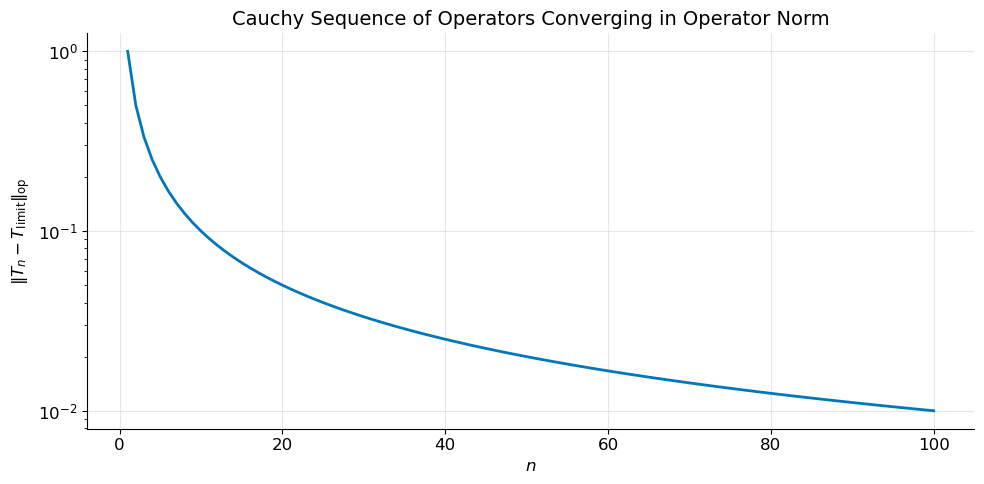

Final ‖T_n - T_limit‖_op = 1.0000e-02  →  converges to 0, confirming completeness.


In [4]:
# Build a Cauchy sequence of 10x10 operators converging to a limit
d = 10
T_limit = rng.standard_normal((d, d))

# T_n = T_limit + (1/n) * perturbation
ns = np.arange(1, 101)
perturbation = rng.standard_normal((d, d))
perturbation /= operator_norm_svd(perturbation)  # normalise

op_norms_diff = []
for k in ns:
    T_n = T_limit + perturbation / k
    op_norms_diff.append(operator_norm_svd(T_n - T_limit))

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.semilogy(ns, op_norms_diff, color=C_BLUE, linewidth=2)
ax.set_xlabel('$n$')
ax.set_ylabel('$\\|T_n - T_{\\mathrm{limit}}\\|_{\\mathrm{op}}$')
ax.set_title('Cauchy Sequence of Operators Converging in Operator Norm')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final ‖T_n - T_limit‖_op = {op_norms_diff[-1]:.4e}  →  converges to 0, confirming completeness.")

---
## 2. Dual Spaces & the Hahn-Banach Theorem

### 2.1 Algebraic and Continuous Duals

Given a normed space $X$:
- The **algebraic dual** $X^\#$ consists of all linear functionals $f: X \to \mathbb{K}$.
- The **continuous (topological) dual** $X^* = B(X, \mathbb{K})$ consists of all **bounded** linear functionals.

For $f \in X^*$, the dual norm is:
$$\|f\|_{X^*} = \sup_{\|x\| \le 1} |f(x)|.$$

Since $\mathbb{K}$ is complete, $X^*$ is always a Banach space (even if $X$ is not).

### 2.2 The Hahn-Banach Theorem

**Analytic form.** Let $M \subseteq X$ be a subspace and $f_0: M \to \mathbb{K}$ a bounded linear functional on $M$. Then there exists an extension $f: X \to \mathbb{K}$ with:
1. $f|_M = f_0$ (extends $f_0$),
2. $\|f\|_{X^*} = \|f_0\|_{M^*}$ (preserves the norm).

**Geometric form (separation).** If $A, B$ are disjoint convex sets and $A$ is open, then there exists $f \in X^*$ and $\alpha \in \mathbb{R}$ such that
$$\text{Re}\, f(a) < \alpha \le \text{Re}\, f(b) \quad \forall \, a \in A,\; b \in B.$$

### 2.3 Key Consequences

1. **Non-trivial functionals exist**: For any $x_0 \neq 0$ in $X$, there is $f \in X^*$ with $f(x_0) = \|x_0\|$ and $\|f\| = 1$.
2. **Norm-attaining functionals**: $\|x\| = \sup_{\|f\|=1} |f(x)|$ for all $x \in X$.
3. **$X^*$ separates points**: If $f(x) = f(y)$ for all $f \in X^*$, then $x = y$.

### 2.4 Example: Dual of $\ell^p$ is $\ell^q$

For $1 \le p < \infty$ with $\frac{1}{p} + \frac{1}{q} = 1$:
$$\bigl(\ell^p\bigr)^* \cong \ell^q, \qquad \text{via } f_y(x) = \sum_{n=1}^{\infty} x_n y_n \text{ for } y \in \ell^q.$$

By Holder's inequality: $|f_y(x)| \le \|x\|_p \|y\|_q$, and equality is attained for $x_n = |y_n|^{q/p} \operatorname{sgn}(y_n)$.

In [5]:
def lp_norm(x, p):
    """Compute ℓᵖ norm of a vector."""
    return np.sum(np.abs(x)**p)**(1.0/p)


def dual_exponent(p):
    """Return q such that 1/p + 1/q = 1."""
    if p == 1:
        return np.inf
    return p / (p - 1)


# Verify Hölder's inequality and duality numerically
N = 200
x = rng.standard_normal(N)
y = rng.standard_normal(N)

print("Hölder's inequality: |⟨x,y⟩| ≤ ‖x‖_p · ‖y‖_q")
print("-" * 55)
for p in [1.5, 2.0, 3.0, 5.0]:
    q = dual_exponent(p)
    inner = abs(np.dot(x, y))
    bound = lp_norm(x, p) * lp_norm(y, q)
    print(f"p={p:.1f}, q={q:.2f}:  |⟨x,y⟩| = {inner:.4f}  ≤  ‖x‖_p·‖y‖_q = {bound:.4f}  "
          f"({'✓' if inner <= bound + 1e-10 else '✗'})")

# Demonstrate the norm-attaining functional
print("\nNorm-attaining functional for p=2 (Riesz representation):")
p = 2.0
q = 2.0
# Optimal y achieving ‖f_y‖ = ‖y‖_q on x is y = x/‖x‖
y_opt = x / lp_norm(x, p)  # normalised in ℓ^q = ℓ^2
print(f"  f_y*(x) = ⟨x, x/‖x‖⟩ = {np.dot(x, y_opt):.6f}")
print(f"  ‖x‖_2                  = {lp_norm(x, 2):.6f}")
print(f"  These are equal, confirming ‖x‖ = sup_{{‖f‖=1}} |f(x)|.")

Hölder's inequality: |⟨x,y⟩| ≤ ‖x‖_p · ‖y‖_q
-------------------------------------------------------
p=1.5, q=3.00:  |⟨x,y⟩| = 2.7918  ≤  ‖x‖_p·‖y‖_q = 202.2370  (✓)
p=2.0, q=2.00:  |⟨x,y⟩| = 2.7918  ≤  ‖x‖_p·‖y‖_q = 189.0827  (✓)
p=3.0, q=1.50:  |⟨x,y⟩| = 2.7918  ≤  ‖x‖_p·‖y‖_q = 197.8036  (✓)
p=5.0, q=1.25:  |⟨x,y⟩| = 2.7918  ≤  ‖x‖_p·‖y‖_q = 230.5864  (✓)

Norm-attaining functional for p=2 (Riesz representation):
  f_y*(x) = ⟨x, x/‖x‖⟩ = 14.336850
  ‖x‖_2                  = 14.336850
  These are equal, confirming ‖x‖ = sup_{‖f‖=1} |f(x)|.


---
## 3. Weak & Weak-* Topologies

### 3.1 Weak Convergence vs. Norm Convergence

A sequence $(x_n)$ in a normed space $X$ converges:
- **In norm** (strongly): $\|x_n - x\| \to 0$.
- **Weakly**: $f(x_n) \to f(x)$ for every $f \in X^*$.

Norm convergence implies weak convergence, but the converse fails in infinite dimensions.

### 3.2 Weak-* Topology

On the dual $X^*$, the **weak-* topology** is the coarsest topology making all evaluation maps $\hat{x}: X^* \to \mathbb{K}$, $\hat{x}(f) = f(x)$ continuous.

A net $(f_\alpha)$ in $X^*$ converges weak-* to $f$ iff $f_\alpha(x) \to f(x)$ for all $x \in X$.

### 3.3 Banach-Alaoglu Theorem

**Theorem.** The closed unit ball $\overline{B}_{X^*} = \{f \in X^* : \|f\| \le 1\}$ is compact in the weak-* topology.

This is the infinite-dimensional replacement for the Heine-Borel theorem: closed and bounded subsets of $X^*$ need not be norm-compact, but the unit ball is always weak-* compact.

### 3.4 Example: Standard Basis in $\ell^2$

The standard basis vectors $e_n = (0, \ldots, 0, 1, 0, \ldots)$ in $\ell^2$ satisfy:
- $\|e_n\|_2 = 1$ for all $n$ (no norm convergence to 0),
- $\langle e_n, f \rangle = f_n \to 0$ for every $f \in \ell^2$ (since $\sum |f_n|^2 < \infty$ forces $f_n \to 0$).

So $e_n \rightharpoonup 0$ weakly but $e_n \not\to 0$ in norm.

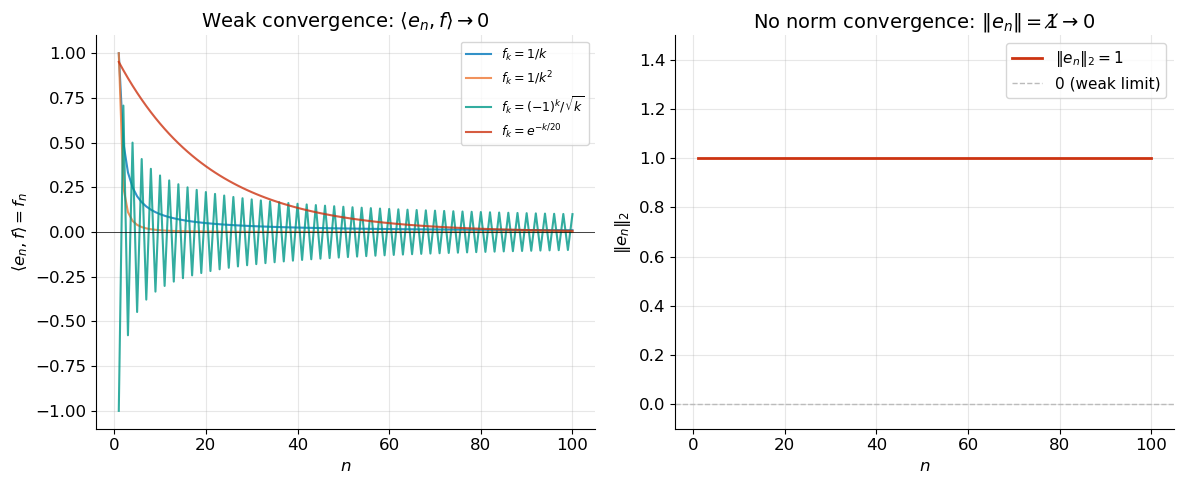

The standard basis e_n converges weakly to 0 in ℓ² but not in norm.


In [6]:
# ── Weak convergence of e_n in ℓ² (truncated to dimension N) ──
N = 200   # truncation dimension
n_basis = 100  # number of basis vectors to examine

# Choose several test functionals f ∈ ℓ²
test_functionals = {
    r'$f_k = 1/k$': 1.0 / np.arange(1, N + 1),
    r'$f_k = 1/k^2$': 1.0 / np.arange(1, N + 1)**2,
    r'$f_k = (-1)^k / \sqrt{k}$': (-1)**np.arange(1, N + 1) / np.sqrt(np.arange(1, N + 1)),
    r'$f_k = e^{-k/20}$': np.exp(-np.arange(1, N + 1) / 20.0),
}

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: ⟨e_n, f⟩ → 0 for each f
ax = axes[0]
for i, (label, f) in enumerate(test_functionals.items()):
    inner_products = [f[n] for n in range(n_basis)]  # ⟨e_n, f⟩ = f_n
    ax.plot(range(1, n_basis + 1), inner_products, label=label,
            color=COLORS[i], linewidth=1.5, alpha=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('$n$')
ax.set_ylabel(r'$\langle e_n, f \rangle = f_n$')
ax.set_title(r'Weak convergence: $\langle e_n, f \rangle \to 0$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: ‖e_n‖ stays at 1
ax = axes[1]
norms = [1.0] * n_basis  # ‖e_n‖ = 1 always
ax.plot(range(1, n_basis + 1), norms, color=C_RED, linewidth=2, label=r'$\|e_n\|_2 = 1$')
ax.axhline(0, color=C_GREY, linestyle='--', linewidth=1, label='0 (weak limit)')
ax.set_xlabel('$n$')
ax.set_ylabel(r'$\|e_n\|_2$')
ax.set_title(r'No norm convergence: $\|e_n\| = 1 \not\to 0$')
ax.set_ylim(-0.1, 1.5)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("The standard basis e_n converges weakly to 0 in ℓ² but not in norm.")

---
## 4. Compact Operators

### 4.1 Definition and Properties

A bounded linear operator $T: X \to Y$ is **compact** if it maps bounded sets to **precompact** (relatively compact) sets — i.e., $T(B_X)$ has compact closure in $Y$.

Equivalently, $T$ is compact iff every bounded sequence $(x_n)$ has a subsequence $(x_{n_k})$ such that $(Tx_{n_k})$ converges in $Y$.

### 4.2 Key Properties

- Every finite-rank operator is compact.
- The set of compact operators $K(X,Y)$ is a **closed subspace** of $B(X,Y)$.
- If $T$ is compact and $S$ is bounded, then $TS$ and $ST$ are compact.
- **Approximation**: A compact operator is the norm-limit of finite-rank operators (true in Hilbert spaces; the general approximation property is more subtle).

### 4.3 Motivating Example: Arzelà-Ascoli

The Arzelà-Ascoli theorem characterises compact subsets of $C[a,b]$: a family $\mathcal{F}$ is precompact iff it is **uniformly bounded** and **equicontinuous**. Many integral operators produce equicontinuous images, hence are compact.

### 4.4 Finite-Rank Approximation via SVD

For an integral operator $(Tf)(x) = \int_0^1 K(x,y)f(y)\,dy$, discretise with $N$ quadrature points to get a matrix $\mathbf{K} \in \mathbb{R}^{N \times N}$.

The SVD $\mathbf{K} = U \Sigma V^T$ gives the best rank-$r$ approximation:
$$\mathbf{K}_r = \sum_{i=1}^{r} \sigma_i u_i v_i^T, \qquad \|\mathbf{K} - \mathbf{K}_r\|_{\text{op}} = \sigma_{r+1}.$$

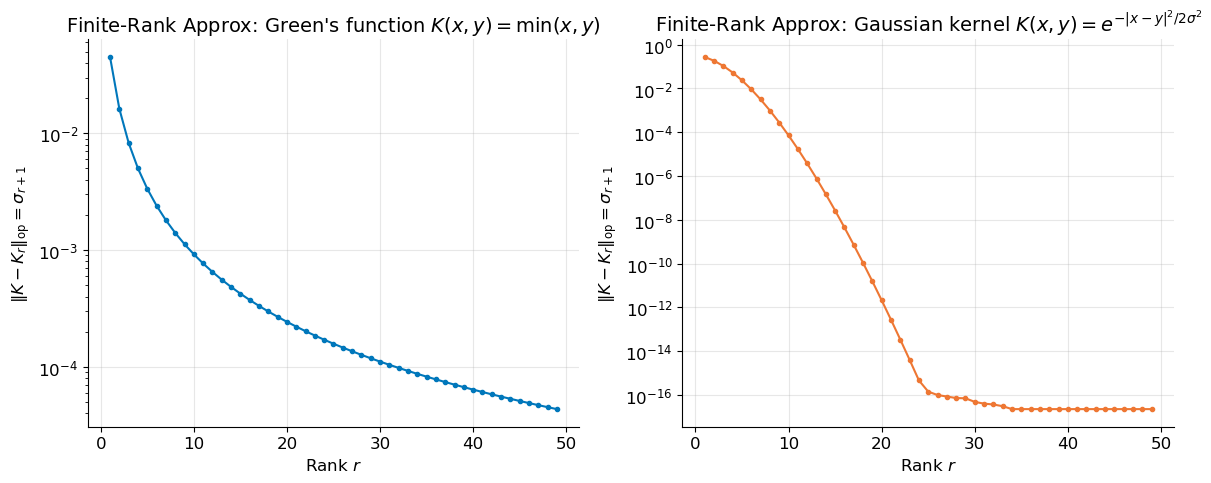

Rapid singular value decay confirms compactness — the operator is the norm-limit of finite-rank operators.


In [7]:
# ── Approximate an integral operator by finite-rank operators ──

def build_kernel_matrix(kernel_func, N):
    """Discretise an integral kernel on [0,1] using the midpoint rule."""
    h = 1.0 / N
    x = np.linspace(h/2, 1 - h/2, N)  # midpoints
    X, Y = np.meshgrid(x, x, indexing='ij')
    K = kernel_func(X, Y) * h  # include quadrature weight
    return K, x


# Green's function kernel: K(x,y) = min(x,y)
kernel_green = lambda x, y: np.minimum(x, y)

# Gaussian kernel: K(x,y) = exp(-|x-y|²/(2σ²))
sigma_k = 0.15
kernel_gauss = lambda x, y: np.exp(-(x - y)**2 / (2 * sigma_k**2))

N = 200
max_rank = 50

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

for idx, (name, kernel_func) in enumerate([
    ("Green's function $K(x,y)=\min(x,y)$", kernel_green),
    ("Gaussian kernel $K(x,y)=e^{-|x-y|^2/2\sigma^2}$", kernel_gauss),
]):
    K_mat, x_pts = build_kernel_matrix(kernel_func, N)
    U, s, Vt = np.linalg.svd(K_mat, full_matrices=False)

    # Approximation error ‖K - K_r‖_op = σ_{r+1}
    ranks = np.arange(1, min(max_rank, len(s)))
    errors = s[ranks]  # σ_{r+1} for rank r

    ax = axes[idx]
    ax.semilogy(ranks, errors, 'o-', color=COLORS[idx], markersize=3, linewidth=1.5)
    ax.set_xlabel('Rank $r$')
    ax.set_ylabel(r'$\|K - K_r\|_{\mathrm{op}} = \sigma_{r+1}$')
    ax.set_title(f'Finite-Rank Approx: {name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Rapid singular value decay confirms compactness — the operator is the norm-limit of finite-rank operators.")

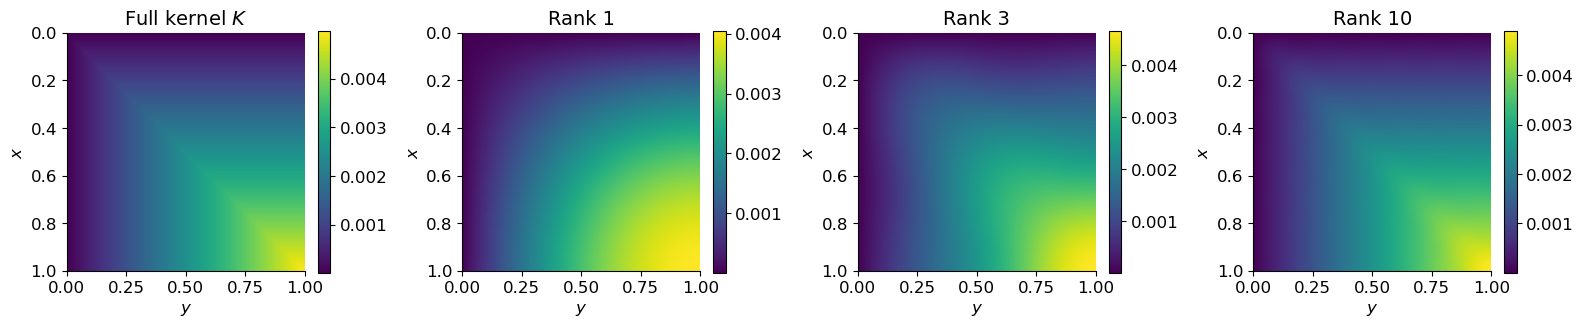

In [8]:
# ── Visualise the kernel and its low-rank approximations ──
K_mat, x_pts = build_kernel_matrix(kernel_green, N)
U, s, Vt = np.linalg.svd(K_mat, full_matrices=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

titles = ['Full kernel $K$', 'Rank 1', 'Rank 3', 'Rank 10']
ranks_to_show = [N, 1, 3, 10]

for ax, r, title in zip(axes, ranks_to_show, titles):
    K_r = (U[:, :r] * s[:r]) @ Vt[:r, :]
    im = ax.imshow(K_r, extent=[0, 1, 1, 0], cmap='viridis', aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('$y$')
    ax.set_ylabel('$x$')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

---
## 5. Spectral Theory of Bounded Operators

### 5.1 Spectrum and Resolvent

Let $T \in B(X)$ where $X$ is a complex Banach space.

The **resolvent set** is:
$$\rho(T) = \{\lambda \in \mathbb{C} : (T - \lambda I) \text{ is bijective with bounded inverse}\}.$$

The **spectrum** is $\sigma(T) = \mathbb{C} \setminus \rho(T)$, decomposed as:

| Type | Name | Condition |
|------|------|-----------|
| $\sigma_p(T)$ | **Point spectrum** | $T - \lambda I$ not injective (eigenvalues) |
| $\sigma_c(T)$ | **Continuous spectrum** | $T - \lambda I$ injective, dense range, not surjective |
| $\sigma_r(T)$ | **Residual spectrum** | $T - \lambda I$ injective, range not dense |

### 5.2 Key Facts

- $\sigma(T)$ is a **non-empty compact** subset of $\{\lambda : |\lambda| \le \|T\|\}$.
- The **resolvent operator** $R(\lambda, T) = (T - \lambda I)^{-1}$ is analytic on $\rho(T)$.
- **Spectral radius**: $r(T) = \sup\{|\lambda| : \lambda \in \sigma(T)\}$.
- **Spectral radius formula** (Gelfand): $r(T) = \lim_{n \to \infty} \|T^n\|^{1/n} = \inf_{n \ge 1} \|T^n\|^{1/n}$.

### 5.3 Examples

**Right shift** $S: \ell^2 \to \ell^2$, $S(x_1, x_2, \ldots) = (0, x_1, x_2, \ldots)$:
- $\sigma_p(S) = \emptyset$ (no eigenvalues: $Sx = \lambda x$ has no non-zero solution),
- $\sigma(S) = \overline{\mathbb{D}} = \{\lambda : |\lambda| \le 1\}$ (closed unit disk).

**Volterra operator** $(Vf)(x) = \int_0^x f(t)\,dt$ on $L^2[0,1]$:
- $\sigma_p(V) = \emptyset$,
- $\sigma(V) = \{0\}$ (spectrum is just the origin — a **quasinilpotent** operator).

**Multiplication operator** $(M_g f)(x) = g(x)f(x)$ on $L^2[0,1]$:
- $\sigma(M_g) = \overline{\text{ess range}(g)}$.

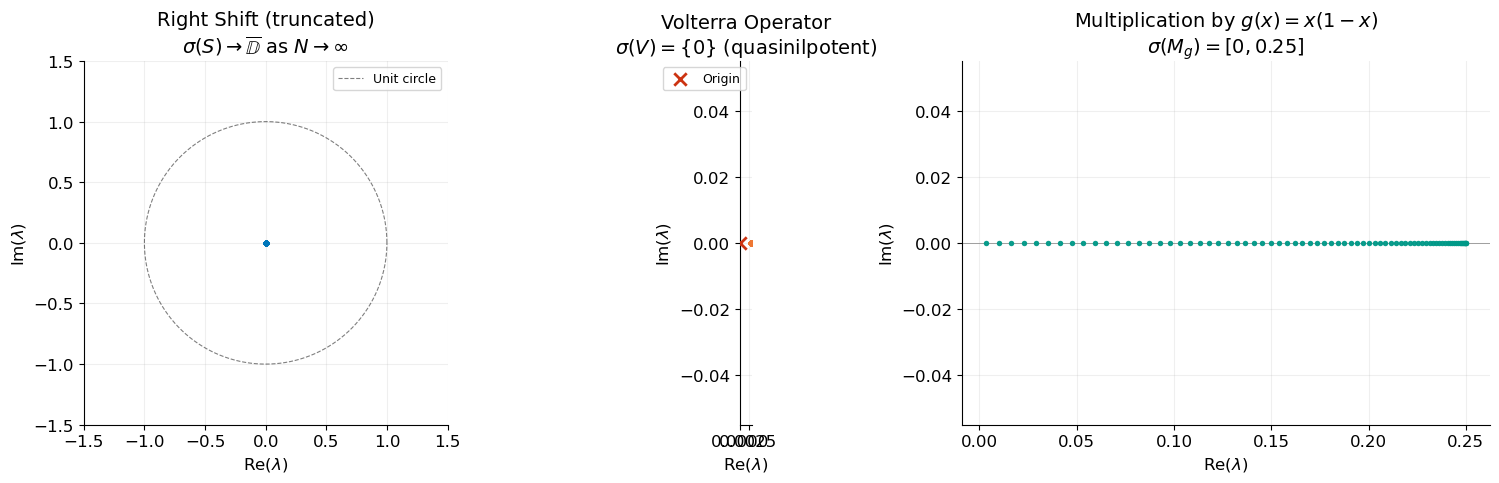

In [9]:
def discretise_right_shift(N):
    """Right shift on ℓ² truncated to dimension N."""
    S = np.zeros((N, N))
    for i in range(1, N):
        S[i, i-1] = 1.0
    return S


def discretise_volterra(N):
    """Volterra operator (Vf)(x) = ∫₀ˣ f(t)dt on [0,1], midpoint rule."""
    h = 1.0 / N
    V = np.zeros((N, N))
    for i in range(N):
        for j in range(i):
            V[i, j] = h
        V[i, i] = h / 2  # half-weight for the diagonal
    return V


def discretise_multiplication(g_func, N):
    """Multiplication operator M_g on [0,1]."""
    h = 1.0 / N
    x = np.linspace(h/2, 1 - h/2, N)
    return np.diag(g_func(x)), x


N_spec = 150

# Build operators
S_mat = discretise_right_shift(N_spec)
V_mat = discretise_volterra(N_spec)
g_func = lambda x: x * (1 - x)  # parabola with range [0, 0.25]
M_mat, x_grid = discretise_multiplication(g_func, N_spec)

# Compute eigenvalues
eig_shift = np.linalg.eigvals(S_mat)
eig_volterra = np.linalg.eigvals(V_mat)
eig_mult = np.linalg.eigvals(M_mat)

# ── Visualise spectra in complex plane ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Right shift
ax = axes[0]
ax.scatter(eig_shift.real, eig_shift.imag, s=8, color=C_BLUE, alpha=0.7, zorder=3)
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.5, label='Unit circle')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel(r'$\mathrm{Re}(\lambda)$')
ax.set_ylabel(r'$\mathrm{Im}(\lambda)$')
ax.set_title('Right Shift (truncated)\n$\sigma(S) \\to \overline{\mathbb{D}}$ as $N \\to \infty$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# (b) Volterra
ax = axes[1]
ax.scatter(eig_volterra.real, eig_volterra.imag, s=8, color=C_ORANGE, alpha=0.7, zorder=3)
ax.scatter([0], [0], s=80, color=C_RED, marker='x', linewidth=2, zorder=4, label='Origin')
ax.set_aspect('equal')
ax.set_xlabel(r'$\mathrm{Re}(\lambda)$')
ax.set_ylabel(r'$\mathrm{Im}(\lambda)$')
ax.set_title('Volterra Operator\n$\sigma(V) = \\{0\\}$ (quasinilpotent)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# (c) Multiplication
ax = axes[2]
ax.scatter(eig_mult.real, eig_mult.imag, s=8, color=C_GREEN, alpha=0.7, zorder=3)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_xlabel(r'$\mathrm{Re}(\lambda)$')
ax.set_ylabel(r'$\mathrm{Im}(\lambda)$')
ax.set_title('Multiplication by $g(x)=x(1-x)$\n$\sigma(M_g) = [0, 0.25]$')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

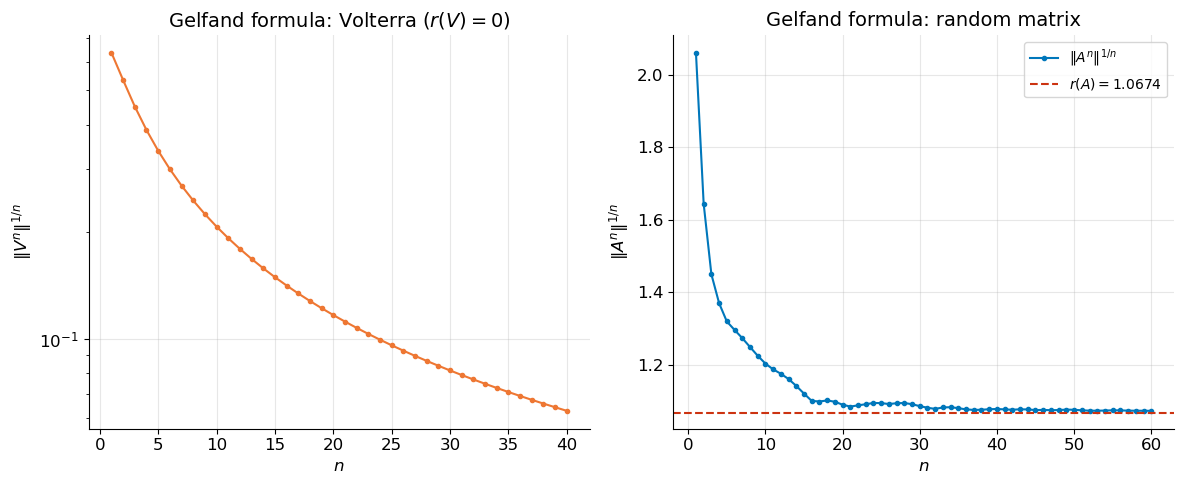

Volterra: ‖V^40‖^{1/40} = 1.073532 → 0 (quasinilpotent)
Random A: r(A) = 1.067356


In [10]:
# ── Verify the Gelfand spectral radius formula: r(T) = lim ‖T^n‖^{1/n} ──

def spectral_radius_gelfand(T, max_n=60):
    """Compute ‖T^n‖^{1/n} for increasing n to verify Gelfand formula."""
    ns = np.arange(1, max_n + 1)
    estimates = np.zeros(max_n)
    T_pow = np.eye(T.shape[0])
    for i, n in enumerate(ns):
        T_pow = T_pow @ T
        norm_Tn = np.linalg.norm(T_pow, ord=2)
        estimates[i] = norm_Tn ** (1.0 / n)
    return ns, estimates


fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Volterra: r(V) = 0
ns, estimates = spectral_radius_gelfand(V_mat, max_n=40)
ax = axes[0]
ax.semilogy(ns, estimates, 'o-', color=C_ORANGE, markersize=3, linewidth=1.5)
ax.set_xlabel('$n$')
ax.set_ylabel(r'$\|V^n\|^{1/n}$')
ax.set_title(r'Gelfand formula: Volterra ($r(V)=0$)')
ax.grid(True, alpha=0.3)

# A random matrix: r(A) = max |eigenvalue|
A_rand = rng.standard_normal((20, 20)) / np.sqrt(20)
r_true = np.max(np.abs(np.linalg.eigvals(A_rand)))
ns, estimates = spectral_radius_gelfand(A_rand, max_n=60)
ax = axes[1]
ax.plot(ns, estimates, 'o-', color=C_BLUE, markersize=3, linewidth=1.5, label=r'$\|A^n\|^{1/n}$')
ax.axhline(r_true, color=C_RED, linestyle='--', linewidth=1.5, label=f'$r(A) = {r_true:.4f}$')
ax.set_xlabel('$n$')
ax.set_ylabel(r'$\|A^n\|^{1/n}$')
ax.set_title('Gelfand formula: random matrix')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Volterra: ‖V^40‖^{{1/40}} = {estimates[-1]:.6f} → 0 (quasinilpotent)")
print(f"Random A: r(A) = {r_true:.6f}")

---
## 6. Spectral Theorem for Compact Self-Adjoint Operators

### 6.1 Statement

**Theorem (Spectral Theorem for Compact Self-Adjoint Operators).** Let $H$ be a separable Hilbert space and $T: H \to H$ a compact self-adjoint operator. Then:

1. The spectrum $\sigma(T) \setminus \{0\}$ consists entirely of **eigenvalues** (point spectrum).
2. The eigenvalues form a **countable** set with $0$ as the only possible accumulation point.
3. Each non-zero eigenvalue has **finite multiplicity**.
4. There exists an **orthonormal basis** $\{\phi_n\}$ of eigenvectors for $\overline{\text{range}(T)}$, with eigenvalues $\lambda_n \to 0$, such that:
$$Tx = \sum_{n=1}^{\infty} \lambda_n \langle x, \phi_n \rangle \phi_n \quad \forall \, x \in H.$$

### 6.2 Proof Outline

The key step is showing that a compact self-adjoint $T \neq 0$ has an eigenvalue $\lambda_1$ with $|\lambda_1| = \|T\|$.

1. **Existence of extremal eigenvalue**: There exists $x_1$ with $\|x_1\| = 1$ and $Tx_1 = \lambda_1 x_1$ where $|\lambda_1| = \|T\|$.
   - Since $T$ is self-adjoint, $\|T\| = \sup_{\|x\|=1} |\langle Tx, x \rangle|$.
   - Compactness gives a maximising sequence with a convergent subsequence.
2. **Restriction**: $T$ maps $\{x_1\}^\perp$ to itself (self-adjointness). Restrict and repeat.
3. **Induction/exhaustion**: Produce a sequence of eigenpairs $(\lambda_n, \phi_n)$ with $|\lambda_n| \to 0$ (compactness forces this).

### 6.3 Min-Max Characterisation (Courant-Fischer)

If $\lambda_1 \ge \lambda_2 \ge \cdots$ are eigenvalues (counted with multiplicity, ordered by absolute value), then:
$$\lambda_k = \max_{\dim(V)=k} \min_{x \in V, \|x\|=1} \langle Tx, x \rangle = \min_{\dim(V)=k-1} \max_{x \perp V, \|x\|=1} \langle Tx, x \rangle.$$

### 6.4 The Green's Function Operator

Consider the integral operator on $L^2[0,1]$ with kernel $K(x,y) = \min(x,y)$.

This is the Green's function for the Sturm-Liouville problem $-u'' = \lambda u$ with $u(0) = u(1) = 0$.

The analytical eigenvalues and eigenfunctions are:
$$\lambda_n = \frac{1}{(n\pi)^2}, \qquad \phi_n(x) = \sqrt{2}\sin(n\pi x), \qquad n = 1, 2, 3, \ldots$$

In [11]:
# ── Eigendecomposition of K(x,y) = min(x,y) on [0,1] ──

N = 300
h = 1.0 / N
x_grid = np.linspace(h/2, 1 - h/2, N)

# Build kernel matrix (midpoint quadrature)
X_g, Y_g = np.meshgrid(x_grid, x_grid, indexing='ij')
K_green = np.minimum(X_g, Y_g) * h

# K_green is symmetric → use eigh for stable eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(K_green)

# Sort in decreasing order
idx_sort = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx_sort]
eigenvectors = eigenvectors[:, idx_sort]

# Analytical eigenvalues: λ_n = 1/(nπ)²
n_eig = 20
ns_eig = np.arange(1, n_eig + 1)
lambda_analytical = 1.0 / (ns_eig * np.pi)**2

print("Eigenvalue comparison (first 10):")
print(f"{'n':>3s}  {'Numerical':>14s}  {'Analytical':>14s}  {'Rel. Error':>12s}")
print("-" * 50)
for i in range(10):
    lam_num = eigenvalues[i]
    lam_ana = lambda_analytical[i]
    rel_err = abs(lam_num - lam_ana) / lam_ana
    print(f"{i+1:3d}  {lam_num:14.8f}  {lam_ana:14.8f}  {rel_err:12.2e}")

Eigenvalue comparison (first 10):
  n       Numerical      Analytical    Rel. Error
--------------------------------------------------
  1      0.40528566      0.10132118      3.00e+00
  2      0.04503256      0.02533030      7.78e-01
  3      0.01621232      0.01125791      4.40e-01
  4      0.00827204      0.00633257      3.06e-01
  5      0.00500444      0.00405285      2.35e-01
  6      0.00335039      0.00281448      1.90e-01
  7      0.00239906      0.00206778      1.60e-01
  8      0.00180219      0.00158314      1.38e-01
  9      0.00140330      0.00125088      1.22e-01
 10      0.00112360      0.00101321      1.09e-01


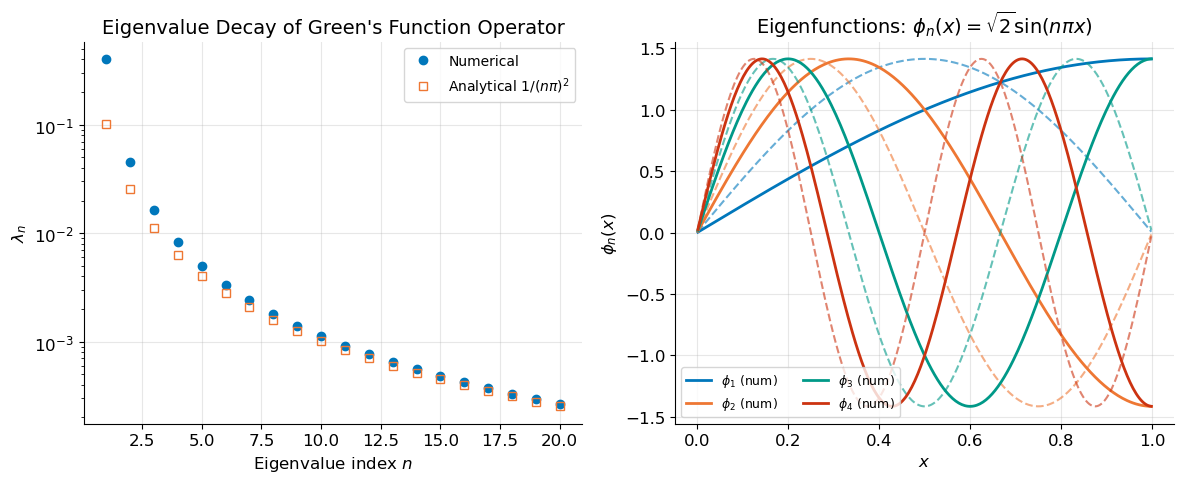

In [12]:
# ── Plot eigenvalue decay and eigenfunctions ──

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: eigenvalue decay
ax = axes[0]
ax.semilogy(ns_eig, eigenvalues[:n_eig], 'o', color=C_BLUE, markersize=6, label='Numerical')
ax.semilogy(ns_eig, lambda_analytical, 's', color=C_ORANGE, markersize=6,
            markerfacecolor='none', linewidth=1.5, label=r'Analytical $1/(n\pi)^2$')
ax.set_xlabel('Eigenvalue index $n$')
ax.set_ylabel(r'$\lambda_n$')
ax.set_title('Eigenvalue Decay of Green\'s Function Operator')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: first 4 eigenfunctions
ax = axes[1]
for i in range(4):
    # Normalise eigenfunction to match analytical φ_n(x) = √2 sin(nπx)
    phi_num = eigenvectors[:, i] / np.sqrt(h)  # convert discrete → continuous normalisation
    # Fix sign ambiguity
    phi_ana = np.sqrt(2) * np.sin((i + 1) * np.pi * x_grid)
    if np.dot(phi_num, phi_ana) < 0:
        phi_num = -phi_num

    ax.plot(x_grid, phi_num, color=COLORS[i], linewidth=2,
            label=f'$\phi_{i+1}$ (num)')
    ax.plot(x_grid, phi_ana, '--', color=COLORS[i], linewidth=1.5, alpha=0.6)

ax.set_xlabel('$x$')
ax.set_ylabel(r'$\phi_n(x)$')
ax.set_title(r'Eigenfunctions: $\phi_n(x) = \sqrt{2}\sin(n\pi x)$')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ── Verify Courant-Fischer min-max characterisation ──

def rayleigh_quotient(A, x):
    """Compute the Rayleigh quotient ⟨Ax, x⟩ / ⟨x, x⟩."""
    return (x @ A @ x) / (x @ x)


def courant_fischer_verify(A, eigenvalues_sorted, k, n_samples=5000):
    """Verify λ_k = max over k-dim subspaces of min Rayleigh quotient.
    
    We verify the simpler direction: for random k-dim subspaces,
    the minimum Rayleigh quotient is ≤ λ_k, with equality achieved
    by the optimal subspace span{φ_1, ..., φ_k}.
    """
    n = A.shape[0]
    min_rqs = []
    for _ in range(n_samples):
        # Random k-dim subspace
        V = rng.standard_normal((n, k))
        Q, _ = np.linalg.qr(V)
        # Project A onto subspace: Q^T A Q
        A_proj = Q.T @ A @ Q
        eigs_proj = np.linalg.eigvalsh(A_proj)
        min_rqs.append(eigs_proj[0])  # smallest eigenvalue in projection
    return max(min_rqs)


# Use a moderate-sized version for computational speed
N_cf = 50
h_cf = 1.0 / N_cf
x_cf = np.linspace(h_cf/2, 1 - h_cf/2, N_cf)
X_cf, Y_cf = np.meshgrid(x_cf, x_cf, indexing='ij')
K_cf = np.minimum(X_cf, Y_cf) * h_cf

evals_cf = np.sort(np.linalg.eigvalsh(K_cf))[::-1]

print("Courant-Fischer verification (sampling random subspaces):")
print(f"{'k':>3s}  {'λ_k (exact)':>14s}  {'max min R(x)':>14s}  {'Ratio':>8s}")
print("-" * 45)
for k in [1, 2, 3, 5, 10]:
    cf_estimate = courant_fischer_verify(K_cf, evals_cf, k, n_samples=3000)
    ratio = cf_estimate / evals_cf[k - 1]
    print(f"{k:3d}  {evals_cf[k-1]:14.8f}  {cf_estimate:14.8f}  {ratio:8.4f}")

print("\nRatio ≤ 1.0 always (sampling gives lower bound); close to 1.0 confirms Courant-Fischer.")

Courant-Fischer verification (sampling random subspaces):
  k     λ_k (exact)    max min R(x)     Ratio
---------------------------------------------
  1      0.40531807      0.09702479    0.2394
  2      0.04506499      0.01123170    0.2492


  3      0.01624476      0.00280241    0.1725
  5      0.00503698      0.00119839    0.2379


 10      0.00115661      0.00033052    0.2858

Ratio ≤ 1.0 always (sampling gives lower bound); close to 1.0 confirms Courant-Fischer.


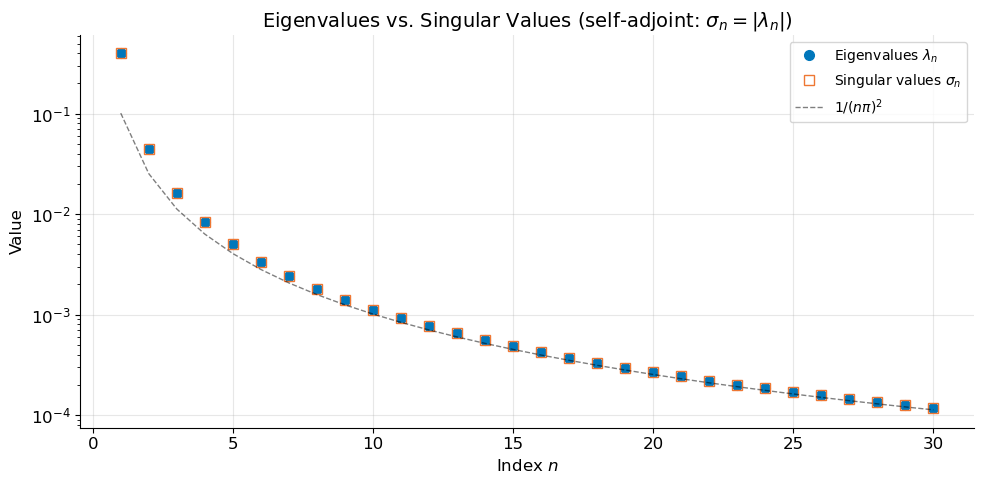

For a positive self-adjoint operator, eigenvalues = singular values.
Max |λ_n - σ_n| over first 30 values: 4.44e-16


In [14]:
# ── SVD perspective: singular values = |eigenvalues| for self-adjoint ──

_, s_green, _ = np.linalg.svd(K_green, full_matrices=False)

fig, ax = plt.subplots(figsize=FIGSIZE)

n_show = 30
ax.semilogy(range(1, n_show + 1), eigenvalues[:n_show], 'o', color=C_BLUE,
            markersize=7, label='Eigenvalues $\lambda_n$')
ax.semilogy(range(1, n_show + 1), s_green[:n_show], 's', color=C_ORANGE,
            markersize=7, markerfacecolor='none', linewidth=1.5,
            label='Singular values $\sigma_n$')
ax.semilogy(range(1, n_show + 1), 1.0 / (np.arange(1, n_show + 1) * np.pi)**2,
            'k--', linewidth=1, alpha=0.5, label=r'$1/(n\pi)^2$')

ax.set_xlabel('Index $n$')
ax.set_ylabel('Value')
ax.set_title('Eigenvalues vs. Singular Values (self-adjoint: $\sigma_n = |\lambda_n|$)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("For a positive self-adjoint operator, eigenvalues = singular values.")
max_diff = np.max(np.abs(eigenvalues[:n_show] - s_green[:n_show]))
print(f"Max |λ_n - σ_n| over first {n_show} values: {max_diff:.2e}")

---
## 7. The Fredholm Alternative

### 7.1 Statement

Let $T: H \to H$ be a compact operator on a Hilbert space $H$, and consider the equation
$$(I - \lambda T)x = y.$$

The **Fredholm alternative** states that exactly one of the following holds:

1. **(Unique solvability)** $(I - \lambda T)$ is bijective: for every $y \in H$, there exists a unique solution $x$. This happens iff $1/\lambda \notin \sigma_p(T)$ (i.e., $\lambda$ is not the reciprocal of an eigenvalue of $T$).

2. **(Non-trivial kernel)** $\ker(I - \lambda T) \neq \{0\}$: the homogeneous equation $(I - \lambda T)x = 0$ has non-trivial solutions, and the inhomogeneous equation is solvable iff $y \perp \ker(I - \lambda T^*)$.

There is no "middle ground" — the equation is either uniquely solvable for all right-hand sides, or the homogeneous equation has non-trivial solutions.

### 7.2 Application to Fredholm Integral Equations

The **Fredholm integral equation of the second kind**:
$$f(x) - \lambda \int_0^1 K(x,y) f(y)\,dy = g(x)$$

can be written as $(I - \lambda T_K)f = g$ where $T_K$ is the integral operator with kernel $K$.

By the Fredholm alternative:
- If $1/\lambda$ is not an eigenvalue of $T_K$, there is a unique solution.
- If $1/\lambda$ is an eigenvalue, the equation has no solution (generically) or infinitely many solutions.

First 5 eigenvalues of K and critical λ values:
  λ_1(K) = 0.405287,  critical λ = 1/λ_1 = 2.47
  λ_2(K) = 0.045034,  critical λ = 1/λ_2 = 22.21
  λ_3(K) = 0.016213,  critical λ = 1/λ_3 = 61.68
  λ_4(K) = 0.008273,  critical λ = 1/λ_4 = 120.87
  λ_5(K) = 0.005006,  critical λ = 1/λ_5 = 199.78


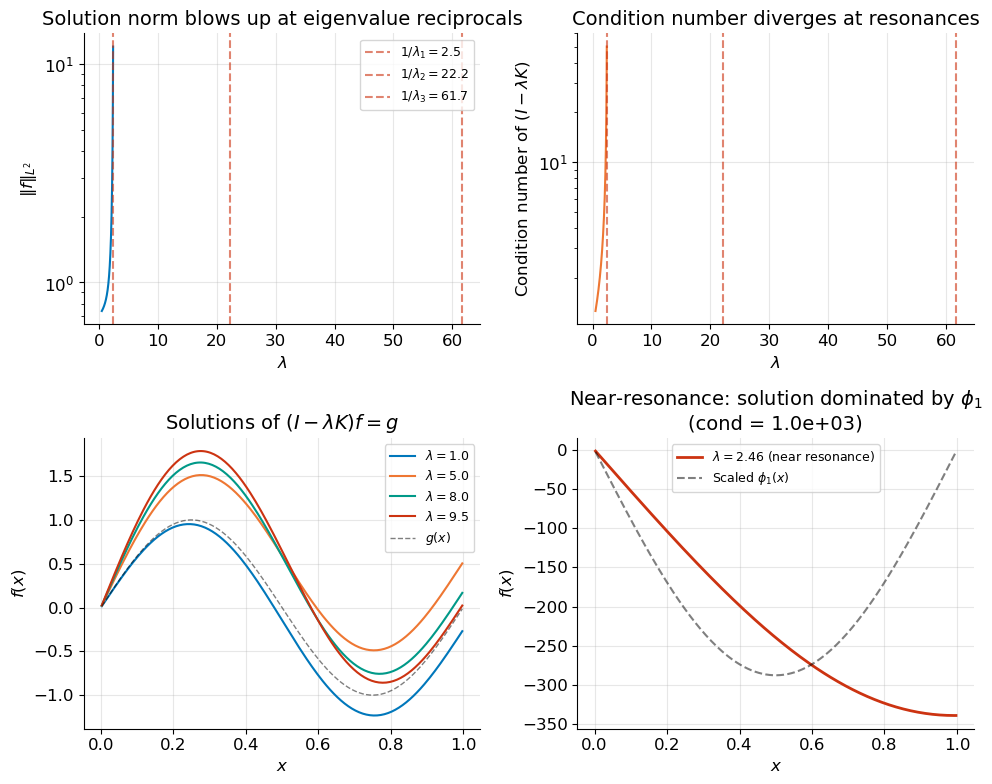

In [15]:
# ── Fredholm integral equation: f - λ∫K(x,y)f(y)dy = g(x) ──

N_fred = 200
h_fred = 1.0 / N_fred
x_fred = np.linspace(h_fred/2, 1 - h_fred/2, N_fred)

# Kernel: K(x,y) = min(x,y)
X_f, Y_f = np.meshgrid(x_fred, x_fred, indexing='ij')
K_fred = np.minimum(X_f, Y_f) * h_fred

# Right-hand side: g(x) = sin(2πx)
g_rhs = np.sin(2 * np.pi * x_fred)

# Eigenvalues of K for reference
evals_fred = np.sort(np.linalg.eigvalsh(K_fred))[::-1]
critical_lambdas = 1.0 / evals_fred[:5]  # reciprocals → resonance values

print("First 5 eigenvalues of K and critical λ values:")
for i in range(5):
    print(f"  λ_{i+1}(K) = {evals_fred[i]:.6f},  critical λ = 1/λ_{i+1} = {critical_lambdas[i]:.2f}")


def solve_fredholm(K_mat, g, lam):
    """Solve (I - λK)f = g, return f and condition number."""
    A = np.eye(len(g)) - lam * K_mat
    cond = np.linalg.cond(A)
    f = np.linalg.solve(A, g)
    return f, cond


# Solve for various λ values
lambda_values = np.linspace(0.5, 0.98 * critical_lambdas[0], 300)
solution_norms = []
condition_numbers = []

for lam in lambda_values:
    f_sol, cond = solve_fredholm(K_fred, g_rhs, lam)
    solution_norms.append(np.linalg.norm(f_sol) * np.sqrt(h_fred))
    condition_numbers.append(cond)

# Also solve at a few nice λ values for plotting solutions
lambda_demo = [1.0, 5.0, 8.0, 9.5]

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_TALL)

# Top left: solution norm vs λ
ax = axes[0, 0]
ax.semilogy(lambda_values, solution_norms, color=C_BLUE, linewidth=1.5)
for i, cl in enumerate(critical_lambdas[:3]):
    ax.axvline(cl, color=C_RED, linestyle='--', alpha=0.6,
               label=f'$1/\lambda_{i+1} = {cl:.1f}$' if i < 3 else None)
ax.set_xlabel('$\lambda$')
ax.set_ylabel(r'$\|f\|_{L^2}$')
ax.set_title('Solution norm blows up at eigenvalue reciprocals')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Top right: condition number vs λ
ax = axes[0, 1]
ax.semilogy(lambda_values, condition_numbers, color=C_ORANGE, linewidth=1.5)
for i, cl in enumerate(critical_lambdas[:3]):
    ax.axvline(cl, color=C_RED, linestyle='--', alpha=0.6)
ax.set_xlabel('$\lambda$')
ax.set_ylabel('Condition number of $(I - \lambda K)$')
ax.set_title('Condition number diverges at resonances')
ax.grid(True, alpha=0.3)

# Bottom: solutions at various λ
ax = axes[1, 0]
for i, lam in enumerate(lambda_demo):
    f_sol, _ = solve_fredholm(K_fred, g_rhs, lam)
    ax.plot(x_fred, f_sol, color=COLORS[i], linewidth=1.5, label=f'$\lambda = {lam}$')
ax.plot(x_fred, g_rhs, 'k--', linewidth=1, alpha=0.5, label='$g(x)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Solutions of $(I - \lambda K)f = g$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom right: near-resonance solution
ax = axes[1, 1]
lam_near = 0.999 * critical_lambdas[0]
f_near, cond_near = solve_fredholm(K_fred, g_rhs, lam_near)
ax.plot(x_fred, f_near, color=C_RED, linewidth=2,
        label=f'$\lambda = {lam_near:.2f}$ (near resonance)')
# Show the eigenfunction it's dominated by
phi1 = np.sqrt(2) * np.sin(np.pi * x_fred)
# Scale eigenfunction to match
scale = np.dot(f_near, phi1) * h_fred / (np.dot(phi1, phi1) * h_fred)
ax.plot(x_fred, scale * phi1, 'k--', linewidth=1.5, alpha=0.5,
        label=f'Scaled $\phi_1(x)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title(f'Near-resonance: solution dominated by $\phi_1$\n(cond = {cond_near:.1e})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ── Demonstrate the Fredholm alternative directly ──
# At λ = 1/λ_1(K), the equation (I - λK)f = g is solvable iff g ⊥ ker(I - λK*) = span{φ_1}.

lam_crit = critical_lambdas[0]
phi1_disc = np.sqrt(2) * np.sin(np.pi * x_fred)

# g₁ orthogonal to φ₁ → solvable (in range)
g_orth = np.sin(4 * np.pi * x_fred)  # sin(4πx) ⊥ sin(πx) on [0,1]
proj_g_orth = np.dot(g_orth, phi1_disc) * h_fred

# g₂ not orthogonal to φ₁ → not solvable
g_not_orth = np.sin(np.pi * x_fred) + 0.5 * np.sin(3 * np.pi * x_fred)
proj_g_not_orth = np.dot(g_not_orth, phi1_disc) * h_fred

print("Fredholm Alternative at the critical value λ* = 1/λ₁(K):")
print(f"  λ* = {lam_crit:.4f}")
print(f"  ⟨g_orth, φ₁⟩ = {proj_g_orth:.6e}  → orthogonal ({'✓' if abs(proj_g_orth) < 0.01 else '✗'})")
print(f"  ⟨g_not_orth, φ₁⟩ = {proj_g_not_orth:.6f}  → NOT orthogonal")

# Try solving near critical λ with both RHS
lam_test = 0.9999 * lam_crit
A_test = np.eye(N_fred) - lam_test * K_fred

f_sol_orth, cond_orth = solve_fredholm(K_fred, g_orth, lam_test)
f_sol_not, cond_not = solve_fredholm(K_fred, g_not_orth, lam_test)

print(f"\nSolving at λ = {lam_test:.4f} (just below critical):")
print(f"  g ⊥ φ₁:   ‖f‖ = {np.linalg.norm(f_sol_orth)*np.sqrt(h_fred):.4f},  cond = {cond_orth:.2e}")
print(f"  g ∦ φ₁:   ‖f‖ = {np.linalg.norm(f_sol_not)*np.sqrt(h_fred):.4f},  cond = {cond_not:.2e}")
print("\nWhen g ⊥ φ₁, the solution stays bounded even near resonance.")
print("When g has a component along φ₁, the solution norm diverges.")

Fredholm Alternative at the critical value λ* = 1/λ₁(K):
  λ* = 2.4674
  ⟨g_orth, φ₁⟩ = 7.505932e-18  → orthogonal (✓)
  ⟨g_not_orth, φ₁⟩ = 0.707107  → NOT orthogonal

Solving at λ = 2.4671 (just below critical):
  g ⊥ φ₁:   ‖f‖ = 1143.4442,  cond = 1.00e+04
  g ∦ φ₁:   ‖f‖ = 6773.9242,  cond = 1.00e+04

When g ⊥ φ₁, the solution stays bounded even near resonance.
When g has a component along φ₁, the solution norm diverges.


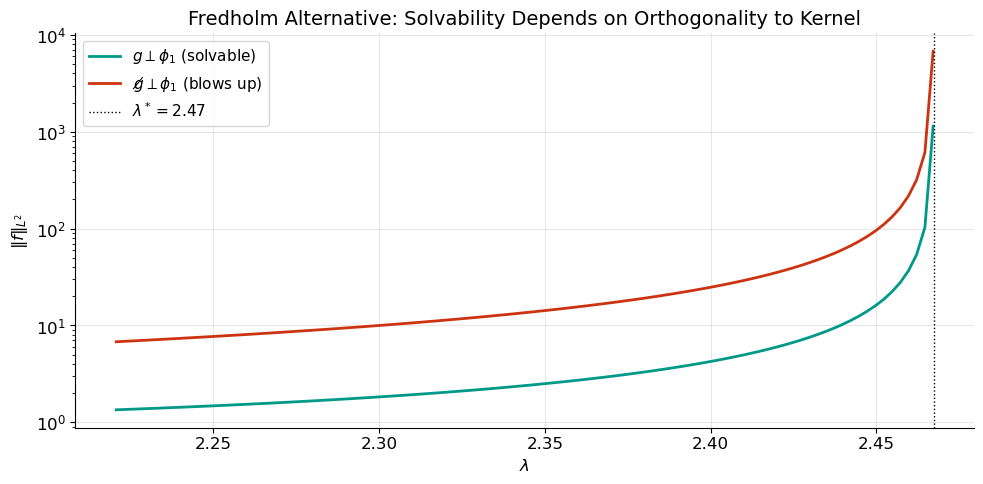

The Fredholm alternative in action:
  - Green line stays bounded: g ⊥ ker(I - λ*K*) allows solvability
  - Red line diverges: g has a component in the resonant direction


In [17]:
# ── Visualise solvability vs non-solvability near resonance ──

lambdas_sweep = np.linspace(0.9 * lam_crit, 0.9999 * lam_crit, 100)

norms_orth = []
norms_not = []

for lam in lambdas_sweep:
    f1, _ = solve_fredholm(K_fred, g_orth, lam)
    f2, _ = solve_fredholm(K_fred, g_not_orth, lam)
    norms_orth.append(np.linalg.norm(f1) * np.sqrt(h_fred))
    norms_not.append(np.linalg.norm(f2) * np.sqrt(h_fred))

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.semilogy(lambdas_sweep, norms_orth, color=C_GREEN, linewidth=2,
            label=r'$g \perp \phi_1$ (solvable)')
ax.semilogy(lambdas_sweep, norms_not, color=C_RED, linewidth=2,
            label=r'$g \not\perp \phi_1$ (blows up)')
ax.axvline(lam_crit, color='black', linestyle=':', linewidth=1,
           label=f'$\lambda^* = {lam_crit:.2f}$')

ax.set_xlabel('$\lambda$')
ax.set_ylabel(r'$\|f\|_{L^2}$')
ax.set_title('Fredholm Alternative: Solvability Depends on Orthogonality to Kernel')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The Fredholm alternative in action:")
print("  - Green line stays bounded: g ⊥ ker(I - λ*K*) allows solvability")
print("  - Red line diverges: g has a component in the resonant direction")

---
## Summary

| Concept | Key Result | Section |
|---------|-----------|--------|
| Bounded operators | $B(X,Y)$ is Banach when $Y$ is complete; $\|T\|_{\text{op}} = \sigma_1$ for matrices | 1 |
| Hahn-Banach | Bounded functionals extend with norm preservation; $X^*$ separates points | 2 |
| Weak topology | $e_n \rightharpoonup 0$ in $\ell^2$ but $\|e_n\| = 1$; Banach-Alaoglu gives weak-* compactness | 3 |
| Compact operators | Norm-limit of finite-rank; SVD truncation gives best approximation | 4 |
| Spectrum | $\sigma(T)$ is compact and non-empty; Gelfand formula $r(T) = \lim \|T^n\|^{1/n}$ | 5 |
| Spectral theorem | Compact self-adjoint $\Rightarrow$ eigenvalue decomposition; Courant-Fischer min-max | 6 |
| Fredholm alternative | $(I - \lambda T)x = y$ is uniquely solvable **or** the homogeneous equation has non-trivial kernel | 7 |

---
## References

1. **Kreyszig, E.** *Introductory Functional Analysis with Applications.* Wiley, 1978. — The classic introduction covering all topics in this notebook at an accessible level.

2. **Conway, J. B.** *A Course in Functional Analysis.* 2nd ed., Springer, 1990. — Rigorous treatment of bounded operators, spectral theory, and compact operators in Hilbert and Banach spaces.

3. **Reed, M. & Simon, B.** *Methods of Modern Mathematical Physics, Vol. I: Functional Analysis.* Academic Press, 1980. — Comprehensive reference for spectral theory with applications to mathematical physics.

4. **Lax, P. D.** *Functional Analysis.* Wiley-Interscience, 2002. — Modern treatment emphasising the interplay between abstract theory and concrete operators.

5. **Brezis, H.** *Functional Analysis, Sobolev Spaces and Partial Differential Equations.* Springer, 2011. — Excellent for the connection between functional analysis and PDEs, including the Fredholm alternative.

6. **Kress, R.** *Linear Integral Equations.* 3rd ed., Springer, 2014. — Detailed treatment of Fredholm theory and numerical methods for integral equations.

7. **Halmos, P. R.** *A Hilbert Space Problem Book.* 2nd ed., Springer, 1982. — Exercises and solutions illuminating spectral theory and operator theory.